## 📦 Import Library

Cell ini mengimpor semua library yang dibutuhkan:
- **TensorFlow/Keras** — membangun dan melatih model LSTM
- **Pandas & NumPy** — manipulasi data tabular dan array numerik
- **Matplotlib & Seaborn** — visualisasi data dan hasil model
- **RobustScaler** — normalisasi data yang tahan terhadap outlier
- **math** — keperluan perhitungan matematis dasar
- **joblib** — menyimpan dan memuat objek Python (misal: scaler)

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import math
import joblib

2026-05-10 09:58:41.258863: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-10 09:58:41.259552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-10 09:58:41.260844: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 09:58:41.268121: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-10 09:58:42.398103: W tensorflow/comp

## Load Data

Sumber Data: PIHPS by Bank Indonesia

### 📥 Load Dataset

Fungsi `load_data()` membaca file CSV dari path yang diberikan dan otomatis mem-parsing kolom `tanggal` menjadi tipe `datetime`. Ini penting agar operasi time-series seperti resampling dan sorting berjalan dengan benar.

In [2]:
def load_data(path='data/cleaned/pihps_cleaned.csv', parse_dates=["tanggal"]):
    # Membaca data CSV dan mem-parsing kolom tanggal
    df = pd.read_csv(path, parse_dates=parse_dates)
    return df

# CONFIG load_data
PATH = "data/cleaned/pihps_cleaned.csv"
PARSE_DATES = ["tanggal"]

# Memuat data ke dalam dataframe dan menampilkan 5 baris pertama
df = load_data(PATH, PARSE_DATES)
df.head()

,Komoditas,tanggal,harga,sumber,is_outlier
0,Bawang Merah Ukuran Sedang,2022-01-03,30200.0,PIHPS,False
1,Bawang Merah Ukuran Sedang,2022-01-04,30150.0,PIHPS,False
2,Bawang Merah Ukuran Sedang,2022-01-05,30300.0,PIHPS,False
3,Bawang Merah Ukuran Sedang,2022-01-06,30300.0,PIHPS,False
4,Bawang Merah Ukuran Sedang,2022-01-07,30400.0,PIHPS,False


## Data Cleaning

### 🔄 Pivot Data berdasarkan Tanggal

Fungsi `pivot_by_date()` mengubah format data dari *long format* (satu baris per komoditas per tanggal) menjadi *wide format* (satu baris per tanggal, satu kolom per komoditas). Ini diperlukan agar setiap fitur (komoditas) bisa digunakan sebagai input multivariate ke model LSTM.

Kolom diurutkan alfabetis agar urutan fitur konsisten setiap kali notebook dijalankan.

In [3]:
def pivot_by_date(df, index_col='tanggal', columns_col='Komoditas', values_col='harga', agg_func='mean'):
    df_work = df.copy()
    
    # Membuat pivot table berdasarkan tanggal (otomatis tanggal jadi index)
    pivot_df = df_work.pivot_table(index=index_col,
                              columns=columns_col,
                              values=values_col,
                              aggfunc=agg_func).sort_index()

    # Mengurutkan nama kolom secara alfabetis agar konsisten
    pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)

    # Mengembalikan index menjadi default
    pivot_df = pivot_df.reset_index()

    # Menghilangkan nama axis 'Komoditas' yang mengambang di atas kolom
    pivot_df.columns.name = None

    return pivot_df

#CONFIG pivot_by_date
INDEX_COL = 'tanggal'
COLUMNS_COL = 'Komoditas'
VALUES_COL = 'harga'
AGG_FUNC = 'mean'

# Contoh penggunaan untuk membuat dataframe pivot
pivoted_df = pivot_by_date(df, INDEX_COL, COLUMNS_COL, VALUES_COL, AGG_FUNC)
pivoted_df.head()

,tanggal,Bawang Merah Ukuran Sedang,Bawang Putih Ukuran Sedang,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,Beras Kualitas Super II,Cabai Merah Besar,...,Cabai Rawit Merah,Daging Ayam Ras Segar,Daging Sapi Kualitas 1,Daging Sapi Kualitas 2,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam Ras Segar
0,2022-01-03,30200.0,30150.0,10750.0,10400.0,11750.0,11550.0,13050.0,12600.0,47250.0,...,86700.0,38100.0,128650.0,119300.0,15250.0,13350.0,18550.0,20700.0,20200.0,30250.0
1,2022-01-04,30150.0,30250.0,10750.0,10450.0,11750.0,11550.0,13050.0,12600.0,47200.0,...,85200.0,38250.0,128600.0,118300.0,15250.0,13350.0,18550.0,20750.0,20200.0,30100.0
2,2022-01-05,30300.0,30300.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,46200.0,...,81800.0,38200.0,128450.0,118950.0,15250.0,13350.0,18550.0,20750.0,20250.0,30350.0
3,2022-01-06,30300.0,30300.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,44850.0,...,77200.0,38350.0,128400.0,118900.0,15250.0,13350.0,18600.0,20800.0,20300.0,29900.0
4,2022-01-07,30400.0,30250.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,43750.0,...,74500.0,38400.0,128400.0,118900.0,15250.0,13350.0,18600.0,20800.0,20300.0,29750.0


### 📆 Resampling Harian & Interpolasi

Fungsi `daily_resampling()` memastikan data memiliki frekuensi harian yang lengkap (tidak ada tanggal yang loncat). Tanggal yang tidak ada datanya akan diisi menggunakan **interpolasi linear** — yaitu mengisi nilai tengah antara dua titik data yang ada. Metode ini cocok untuk data harga yang bergerak relatif mulus.

In [4]:
def daily_resampling(df, date_col='tanggal', interpolation_method='linear'):
    # Salin dataframe agar tidak mengubah objek aslinya
    df_work = df.copy()

    # Pindahkan kolom tanggal ke index agar .asfreq() bisa bekerja
    df_work = df_work.set_index(date_col)
    
    # Pastikan index terurut agar tidak ada error saat resampling
    df_work = df_work.sort_index()

    # Melakukan resampling harian (mengisi tanggal yang terlewat)
    df_resampled = df_work.asfreq('D')
    
    # Interpolasi untuk mengisi nilai NaN pada tanggal yang baru dibuat
    df_final = df_resampled.interpolate(method=interpolation_method)

    # Kembalikan index (tanggal) menjadi kolom biasa
    df_final = df_final.reset_index()

    return df_final

#CONFIG daily_resampling
DATE_COL = 'tanggal'
INTERPOLATION_METHOD = 'linear'

# Jalankan fungsi untuk membuat dataframe hasil harian
df_daily = daily_resampling(pivoted_df, DATE_COL, INTERPOLATION_METHOD)
df_daily.head()

,tanggal,Bawang Merah Ukuran Sedang,Bawang Putih Ukuran Sedang,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,Beras Kualitas Super II,Cabai Merah Besar,...,Cabai Rawit Merah,Daging Ayam Ras Segar,Daging Sapi Kualitas 1,Daging Sapi Kualitas 2,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam Ras Segar
0,2022-01-03,30200.0,30150.0,10750.0,10400.0,11750.0,11550.0,13050.0,12600.0,47250.0,...,86700.0,38100.0,128650.0,119300.0,15250.0,13350.0,18550.0,20700.0,20200.0,30250.0
1,2022-01-04,30150.0,30250.0,10750.0,10450.0,11750.0,11550.0,13050.0,12600.0,47200.0,...,85200.0,38250.0,128600.0,118300.0,15250.0,13350.0,18550.0,20750.0,20200.0,30100.0
2,2022-01-05,30300.0,30300.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,46200.0,...,81800.0,38200.0,128450.0,118950.0,15250.0,13350.0,18550.0,20750.0,20250.0,30350.0
3,2022-01-06,30300.0,30300.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,44850.0,...,77200.0,38350.0,128400.0,118900.0,15250.0,13350.0,18600.0,20800.0,20300.0,29900.0
4,2022-01-07,30400.0,30250.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,43750.0,...,74500.0,38400.0,128400.0,118900.0,15250.0,13350.0,18600.0,20800.0,20300.0,29750.0


### 📈 Visualisasi Tren per Komoditas

Cell ini menampilkan line chart untuk setiap komoditas dalam satu figure. Berguna untuk melihat secara sekilas pola tren, lonjakan, atau anomali pada masing-masing komoditas sebelum masuk ke proses pemodelan.

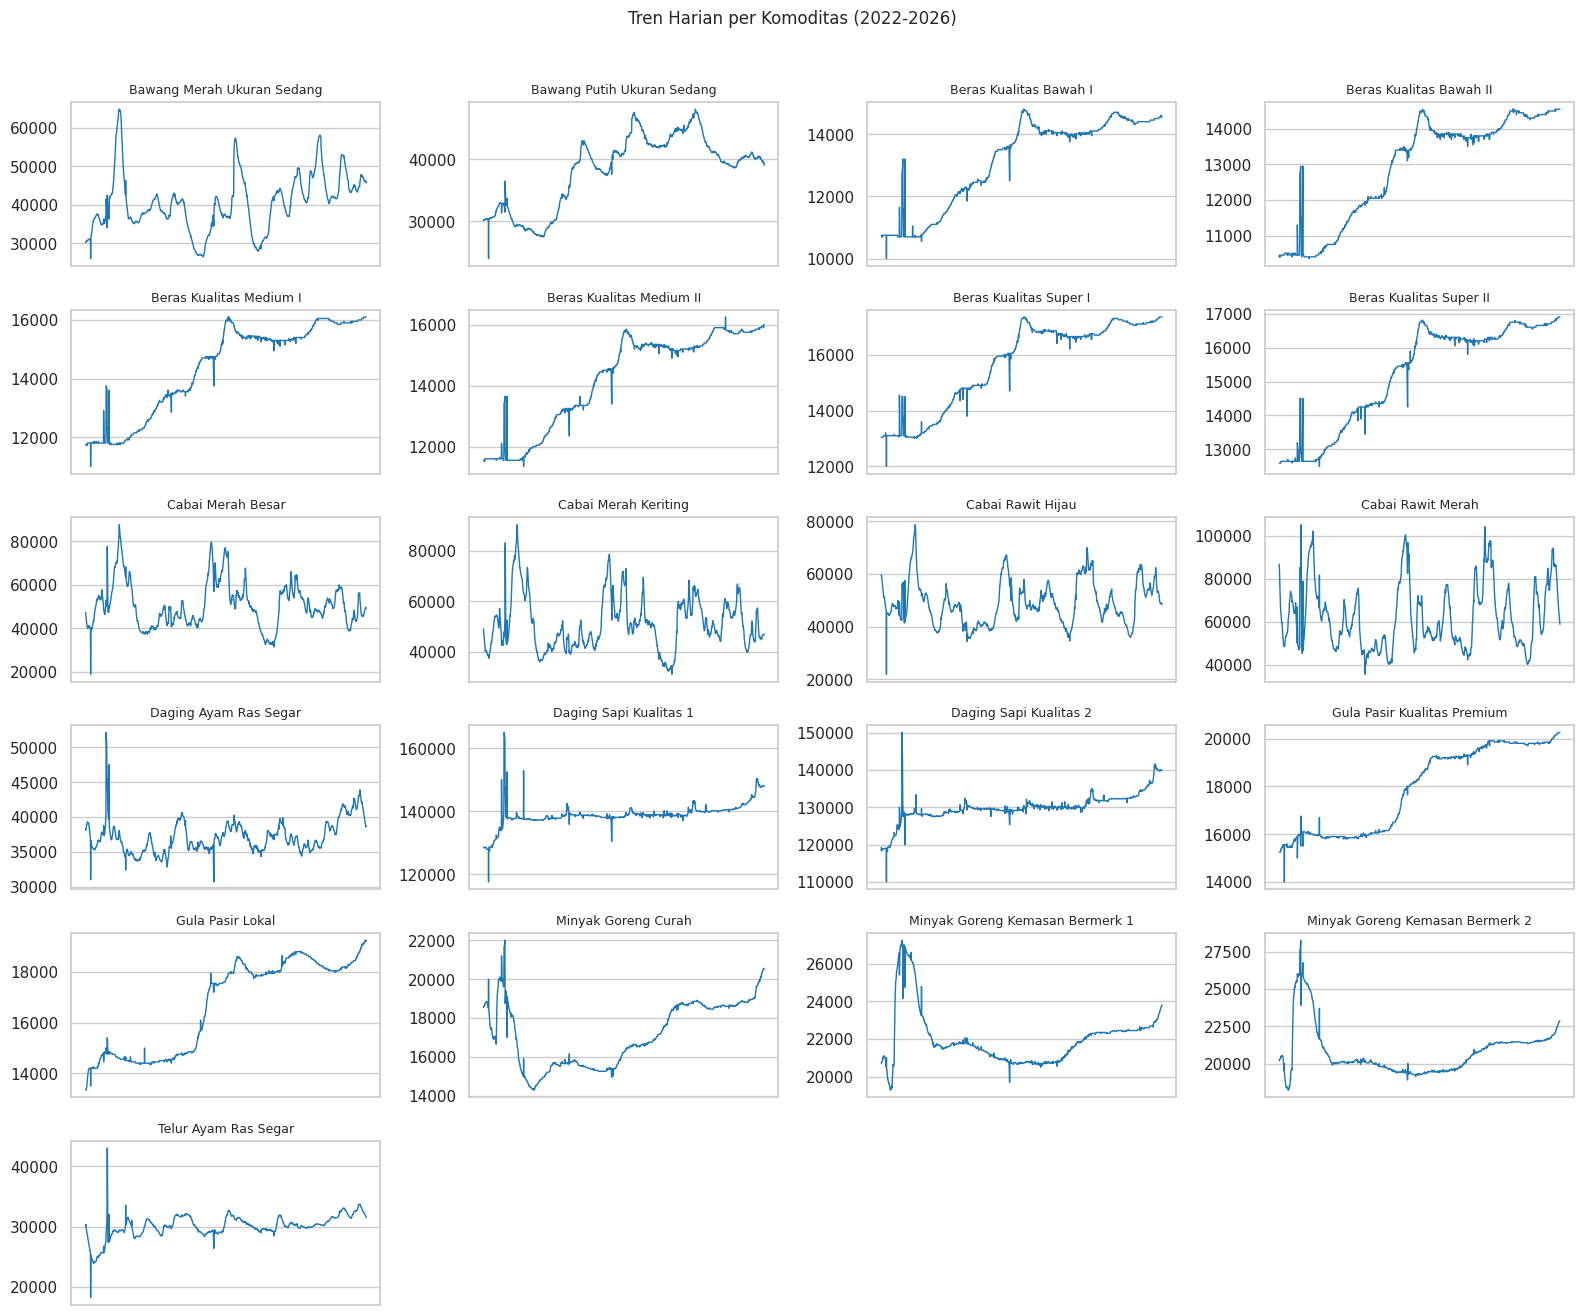

In [5]:
# Siapkan data kolom numerik selain tanggal
DATE_COL = 'tanggal'
NUM_COLS = [col for col in df_daily.columns if col != DATE_COL]

# Konfigurasi gaya seaborn
sns.set(style="whitegrid")

# Tentukan layout subplot yang rapi (misal 4 kolom)
N_COLS = 4
N_PLOTS = len(NUM_COLS)
N_ROWS = math.ceil(N_PLOTS / N_COLS)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(4*N_COLS, 2.2*N_ROWS), sharex=False)
axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    sns.lineplot(data=df_daily, x=DATE_COL, y=col, ax=ax, color="#1f77b4", linewidth=1)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # Hapus xticks agar rapi
    ax.set_xticks([])

# Kosongkan axis yang tidak terpakai jika jumlah subplot lebih banyak dari kolom
for i in range(N_PLOTS, len(axes)):
    axes[i].axis('off')

fig.suptitle("Tren Harian per Komoditas (2022-2026)", fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 🗑️ Hapus Kolom Tanggal

Kolom `tanggal` dihapus sebelum data dimasukkan ke model karena LSTM hanya menerima input numerik. Informasi urutan waktu sudah terepresentasi secara implisit melalui urutan baris dalam array.

In [6]:
def remove_date(df, date_col="tanggal"):
    df = df.drop(columns=[date_col])
    return df

# CONFIG remove_date
DATE_COL = "tanggal"

df_final = remove_date(df_daily, date_col=DATE_COL)
df_final.head()

,Bawang Merah Ukuran Sedang,Bawang Putih Ukuran Sedang,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,Beras Kualitas Super II,Cabai Merah Besar,Cabai Merah Keriting,...,Cabai Rawit Merah,Daging Ayam Ras Segar,Daging Sapi Kualitas 1,Daging Sapi Kualitas 2,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam Ras Segar
0,30200.0,30150.0,10750.0,10400.0,11750.0,11550.0,13050.0,12600.0,47250.0,49000.0,...,86700.0,38100.0,128650.0,119300.0,15250.0,13350.0,18550.0,20700.0,20200.0,30250.0
1,30150.0,30250.0,10750.0,10450.0,11750.0,11550.0,13050.0,12600.0,47200.0,48400.0,...,85200.0,38250.0,128600.0,118300.0,15250.0,13350.0,18550.0,20750.0,20200.0,30100.0
2,30300.0,30300.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,46200.0,47700.0,...,81800.0,38200.0,128450.0,118950.0,15250.0,13350.0,18550.0,20750.0,20250.0,30350.0
3,30300.0,30300.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,44850.0,46800.0,...,77200.0,38350.0,128400.0,118900.0,15250.0,13350.0,18600.0,20800.0,20300.0,29900.0
4,30400.0,30250.0,10700.0,10400.0,11750.0,11550.0,13050.0,12600.0,43750.0,45450.0,...,74500.0,38400.0,128400.0,118900.0,15250.0,13350.0,18600.0,20800.0,20300.0,29750.0


## 🔀 Pembagian Data & Preprocessing

## ✂️ Split Data: Train / Validation / Test

Fungsi `split_timeseries()` membagi data secara **sequential** (tidak diacak) sesuai urutan waktu:
- **Train (70%)** — digunakan untuk melatih model
- **Validation (15%)** — memantau performa selama training (early stopping)
- **Test (15%)** — evaluasi akhir model pada data yang belum pernah dilihat

> ⚠️ Pembagian harus sequential (tidak random) karena data time-series memiliki ketergantungan temporal.

In [7]:
def split_timeseries(df, train_pct=70):
    # sisa dari train dibagi rata 50/50 ke val dan test
    # contoh: train_pct=70 → 70% train, 15% val, 15% test

    # hitung jumlah baris
    n = len(df)

    # hitung index potong
    train_idx = int(n * train_pct / 100)
    val_idx   = int(n * (train_pct + (100 - train_pct) / 2) / 100)

    # slice berdasarkan index
    train_df = df.iloc[:train_idx].values
    val_df   = df.iloc[train_idx:val_idx].values
    test_df  = df.iloc[val_idx:].values

    # logging
    sisa_pct = 100 - train_pct
    val_pct  = sisa_pct / 2
    print(f"Total baris: {n}")
    print(f"Train ({train_pct}%)  : {len(train_df)} baris")
    print(f"Valid ({val_pct}%) : {len(val_df)} baris")
    print(f"Test  ({val_pct}%) : {len(test_df)} baris")

    return train_df, val_df, test_df

# CONFIG split_timeseries
TRAIN_PCT = 70  # sisa (30%) otomatis dibagi rata → 15% val, 15% test

# pemakaian
train_df, val_df, test_df = split_timeseries(df_final, train_pct=TRAIN_PCT)

Total baris: 1579
Train (70%)  : 1105 baris
Valid (15.0%) : 237 baris
Test  (15.0%) : 237 baris


### ⚖️ Scaling dengan RobustScaler

**RobustScaler** melakukan normalisasi berdasarkan median dan IQR (Interquartile Range), sehingga lebih tahan terhadap outlier dibanding StandardScaler.

> ⚠️ **Penting**: `fit_transform()` hanya dilakukan pada data **train**. Data validation dan test hanya di-`transform()` menggunakan statistik dari train untuk menghindari *data leakage*.

In [8]:
# Fit scaler hanya pada data latih, lalu transformasi semua bagian
scaler = RobustScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

### 🔍 Cek Hasil Scaling

Memverifikasi bahwa scaling berjalan dengan benar. Nilai yang dihasilkan RobustScaler tidak selalu berada di range [0,1], tetapi seharusnya terpusat di sekitar 0.

In [9]:
# Cek nilai statistik dari data yang telah di scale
print(f"Nilai Minimal Hasil Scale   : {train_scaled.min()}")
print(f"Nilai Rata-rata Hasil Scale : {train_scaled.mean()}")
print(f"Nilai Maximum Hasil Scale   : {train_scaled.max()}")

Nilai Minimal Hasil Scale   : -17.361111111111118
Nilai Rata-rata Hasil Scale : 0.1113224006986013
Nilai Maximum Hasil Scale   : 22.222222222222214


### 🪟 Windowed Dataset (Sliding Window)

Fungsi `windowed_dataset()` mengubah array time-series menjadi pasangan **(X, y)** menggunakan teknik **sliding window**:
- **X** (`n_past` langkah ke belakang) — data historis sebagai input
- **y** (`n_future` langkah ke depan) — target prediksi

Dataset ini dibangun menggunakan `tf.data.Dataset` yang efisien untuk pipeline training TensorFlow. `prefetch(1)` memastikan batch berikutnya sudah siap saat GPU/CPU memproses batch saat ini.

In [16]:
def windowed_dataset(array, batch_size=32, n_past=7, n_future=1, shift=1):
    # Ubah array numpy menjadi dataset TensorFlow
    ds = tf.data.Dataset.from_tensor_slices(array)
    
    # Buat jendela geser sepanjang (n_past + n_future) dengan langkah shift
    ds = ds.window(size=n_past + n_future, shift=shift, drop_remainder=True)
    
    # Gabungkan setiap jendela menjadi satu tensor penuh
    ds = ds.flat_map(lambda w: w.batch(n_past + n_future))
    
    # Pisahkan jendela menjadi input (n_past) dan target (n_future)
    ds = ds.map(lambda w: (w[:n_past], w[n_past:]))
    
    # Kelompokkan ke dalam batch dan prefetch untuk efisiensi pipeline
    return ds.batch(batch_size).prefetch(1)

# CONFIG
BATCH_SIZE = 8
N_PAST = 7
N_FEATURES = len(df_final.columns)
N_FUTURE = 1

train_set = windowed_dataset(train_scaled, batch_size=BATCH_SIZE, n_past=N_PAST, n_future=N_FUTURE)
valid_set = windowed_dataset(val_scaled, batch_size=BATCH_SIZE, n_past=N_PAST, n_future=N_FUTURE)
test_set = windowed_dataset(test_scaled, batch_size=BATCH_SIZE, n_past=N_PAST, n_future=N_FUTURE)

## 🧠 Arsitektur Model LSTM

Model dibangun menggunakan **Stacked LSTM** dengan beberapa lapisan regulasi:

| Layer | Output | Keterangan |
|---|---|---|
| LSTM(64) | (batch, N_PAST, 64) | Layer LSTM pertama, mengembalikan seluruh sequence |
| Dropout(0.6) | — | Mencegah overfitting dengan mematikan 60% neuron secara acak |
| LSTM(32) | (batch, 32) | Layer LSTM kedua, hanya output terakhir |
| Dropout(0.4) | — | Regulasi tambahan |
| Dense(16, relu) | (batch, 16) | Lapisan fully-connected untuk representasi akhir |
| Dropout(0.2) | — | Regulasi ringan sebelum output |
| Dense(N_FEATURES) | (batch, N_FEATURES) | Output: prediksi harga semua komoditas |

**Loss**: MAE | **Optimizer**: Adam (lr=1e-3) | **Early Stopping**: patience=20, mulai epoch ke-50

In [18]:
# CONFIG model
N_PAST     = 7
N_FUTURE   = 1
N_FEATURES = len(df_final.columns)

# Arsitektur model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(N_PAST, N_FEATURES), return_sequences=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(N_FEATURES)
])

# Callbacks
callbacks = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         
    patience=20,                
    restore_best_weights=True,  
    start_from_epoch=50      
)

# Compile
model.compile(
    loss='mae',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['mae']
)

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 7, 64)             22016     
                                                                 
 dropout_6 (Dropout)         (None, 7, 64)             0         
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_7 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dropout_8 (Dropout)         (None, 16)                0         
                                                                 
 dense_5 (Dense)             (None, 21)               

### 🏋️ Training Model

Model dilatih selama maksimum 200 epoch dengan early stopping. Training akan otomatis berhenti jika `val_loss` tidak membaik selama 20 epoch berturut-turut, dan bobot terbaik akan otomatis dipulihkan (`restore_best_weights=True`).

In [20]:
# Training
history = model.fit(
    train_set, 
    validation_data=valid_set, 
    epochs=200, 
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
138/138 [==============================] - 5s 15ms/step - loss: 0.5905 - mae: 0.5904 - val_loss: 0.6610 - val_mae: 0.6610
Epoch 2/200
138/138 [==============================] - 1s 9ms/step - loss: 0.5367 - mae: 0.5366 - val_loss: 0.6062 - val_mae: 0.6061
Epoch 3/200
138/138 [==============================] - 1s 9ms/step - loss: 0.4950 - mae: 0.4948 - val_loss: 0.5669 - val_mae: 0.5667
Epoch 4/200
138/138 [==============================] - 1s 9ms/step - loss: 0.4650 - mae: 0.4651 - val_loss: 0.5435 - val_mae: 0.5433
Epoch 5/200
138/138 [==============================] - 1s 8ms/step - loss: 0.4486 - mae: 0.4486 - val_loss: 0.5275 - val_mae: 0.5272
Epoch 6/200
138/138 [==============================] - 1s 8ms/step - loss: 0.4239 - mae: 0.4238 - val_loss: 0.5280 - val_mae: 0.5278
Epoch 7/200
138/138 [==============================] - 1s 8ms/step - loss: 0.4204 - mae: 0.4203 - val_loss: 0.4899 - val_mae: 0.4898
Epoch 8/200
138/138 [==============================] - 1s 8ms/step -

### 📉 Plot Learning Curves

Fungsi `plot_regression_learning_curves()` memvisualisasikan MAE training vs validation per epoch. Grafik ini digunakan untuk mendiagnosis apakah model mengalami:
- **Underfitting** — kedua kurva masih tinggi
- **Overfitting** — training MAE turun tapi val MAE naik
- **Good fit** — kedua kurva konvergen ke nilai rendah

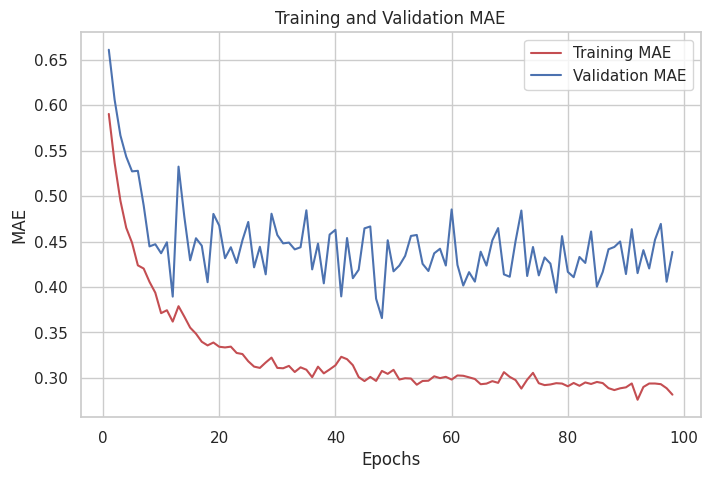

In [22]:
# Plot learning curves
def plot_regression_learning_curves(history):
    # Mengambil data metrik MAE langsung dari history
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(mae) + 1)

    plt.figure(figsize=(8, 5))

    # Plot garis untuk Training dan Validation MAE
    plt.plot(epochs, mae, 'r-', label='Training MAE')
    plt.plot(epochs, val_mae, 'b-', label='Validation MAE')
    
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

    plt.show()

# Panggil fungsi learning curvesZz
plot_regression_learning_curves(history)

## 📊 Evaluasi Model

Setelah training selesai, model dievaluasi pada **data test** yang belum pernah dilihat model. Metrik yang digunakan:

| Metrik | Rumus | Interpretasi |
|---|---|---|
| **MAE** | mean(\|y - ŷ\|) | Rata-rata error absolut dalam satuan asli |
| **RMSE** | √mean((y - ŷ)²) | Lebih sensitif terhadap error besar |
| **MAPE** | mean(\|y - ŷ\| / \|y\|) × 100 | Error dalam persentase, mudah diinterpretasikan |

Evaluasi dilakukan per komoditas agar terlihat mana yang prediksinya paling akurat atau paling sulit.

In [24]:
# ============================================================
# EVALUASI MODEL PADA DATA TEST
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----------------------------------------------------------
# 1. Kumpulkan semua prediksi & nilai aktual dari test_set
# ----------------------------------------------------------
# Model memprediksi dalam skala yang sudah dinormalisasi,
# jadi kita perlu mengumpulkan semua batch terlebih dahulu.
y_true_scaled_list = []
y_pred_scaled_list = []

for X_batch, y_batch in test_set:
    preds = model.predict(X_batch, verbose=0)          # prediksi (scaled)
    y_true_scaled_list.append(y_batch.numpy())         # aktual (scaled)
    y_pred_scaled_list.append(preds)

# Gabungkan semua batch menjadi satu array
y_true_scaled = np.concatenate(y_true_scaled_list, axis=0)   # shape: (n_samples, 1, N_FEATURES)
y_pred_scaled = np.concatenate(y_pred_scaled_list, axis=0)   # shape: (n_samples, N_FEATURES)

# Karena N_FUTURE=1, squeeze dimensi tengah
y_true_scaled = y_true_scaled.squeeze(axis=1)                 # (n_samples, N_FEATURES)

print(f"Shape y_true (scaled): {y_true_scaled.shape}")
print(f"Shape y_pred (scaled): {y_pred_scaled.shape}")

# ----------------------------------------------------------
# 2. Inverse transform → kembalikan ke skala harga asli (Rp)
# ----------------------------------------------------------
# Sangat penting! Evaluasi harus dilakukan pada skala asli
# agar metrik (MAE, RMSE, MAPE) punya makna nyata dalam rupiah.
y_true = scaler.inverse_transform(y_true_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)

# ----------------------------------------------------------
# 3. Hitung metrik per komoditas
# ----------------------------------------------------------
commodity_cols = df_final.columns.tolist()

results = []
for i, col in enumerate(commodity_cols):
    yt = y_true[:, i]
    yp = y_pred[:, i]

    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    # Hindari pembagian dengan nol menggunakan np.where
    mape = np.mean(np.abs((yt - yp) / np.where(yt == 0, 1e-8, yt))) * 100

    results.append({'Komoditas': col, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape})

# Buat dataframe hasil evaluasi dan urutkan berdasarkan MAPE
eval_df = pd.DataFrame(results).sort_values('MAPE (%)')

# Tampilkan tabel evaluasi dengan formatting angka
print("\n=== Hasil Evaluasi Model per Komoditas ===\n")
print(eval_df.to_string(index=False, float_format='%.2f'))


Shape y_true (scaled): (230, 21)
Shape y_pred (scaled): (230, 21)

=== Hasil Evaluasi Model per Komoditas ===

                      Komoditas      MAE     RMSE  MAPE (%)
               Gula Pasir Lokal   310.98   460.91      1.67
        Beras Kualitas Super II   318.68   393.73      1.91
         Beras Kualitas Super I   348.45   418.22      2.03
         Beras Kualitas Bawah I   293.91   363.92      2.03
    Gula Pasir Kualitas Premium   420.11   529.86      2.11
           Telur Ayam Ras Segar   928.94  1136.57      2.85
         Daging Sapi Kualitas 1  4157.93  5133.39      2.86
       Beras Kualitas Medium II   512.66   561.28      3.24
        Beras Kualitas Medium I   517.86   564.46      3.24
         Daging Sapi Kualitas 2  4945.13  5750.65      3.61
        Beras Kualitas Bawah II   532.40   566.91      3.69
          Daging Ayam Ras Segar  1568.56  1897.90      3.80
Minyak Goreng Kemasan Bermerk 1  1007.21  1051.98      4.43
Minyak Goreng Kemasan Bermerk 2  1039.09  1089.72

In [25]:
# ----------------------------------------------------------
# 4. Ringkasan metrik keseluruhan (rata-rata semua komoditas)
# ----------------------------------------------------------
print("\n=== Ringkasan Evaluasi Keseluruhan ===")
print(f"  MAE  rata-rata : Rp {eval_df['MAE'].mean():,.2f}")
print(f"  RMSE rata-rata : Rp {eval_df['RMSE'].mean():,.2f}")
print(f"  MAPE rata-rata : {eval_df['MAPE (%)'].mean():.2f}%")



=== Ringkasan Evaluasi Keseluruhan ===
  MAE  rata-rata : Rp 2,909.08
  RMSE rata-rata : Rp 3,350.38
  MAPE rata-rata : 6.35%


### 📊 Visualisasi Metrik Evaluasi per Komoditas

Bar chart di bawah menampilkan MAPE per komoditas secara visual. Semakin kecil batang, semakin akurat prediksi model untuk komoditas tersebut.

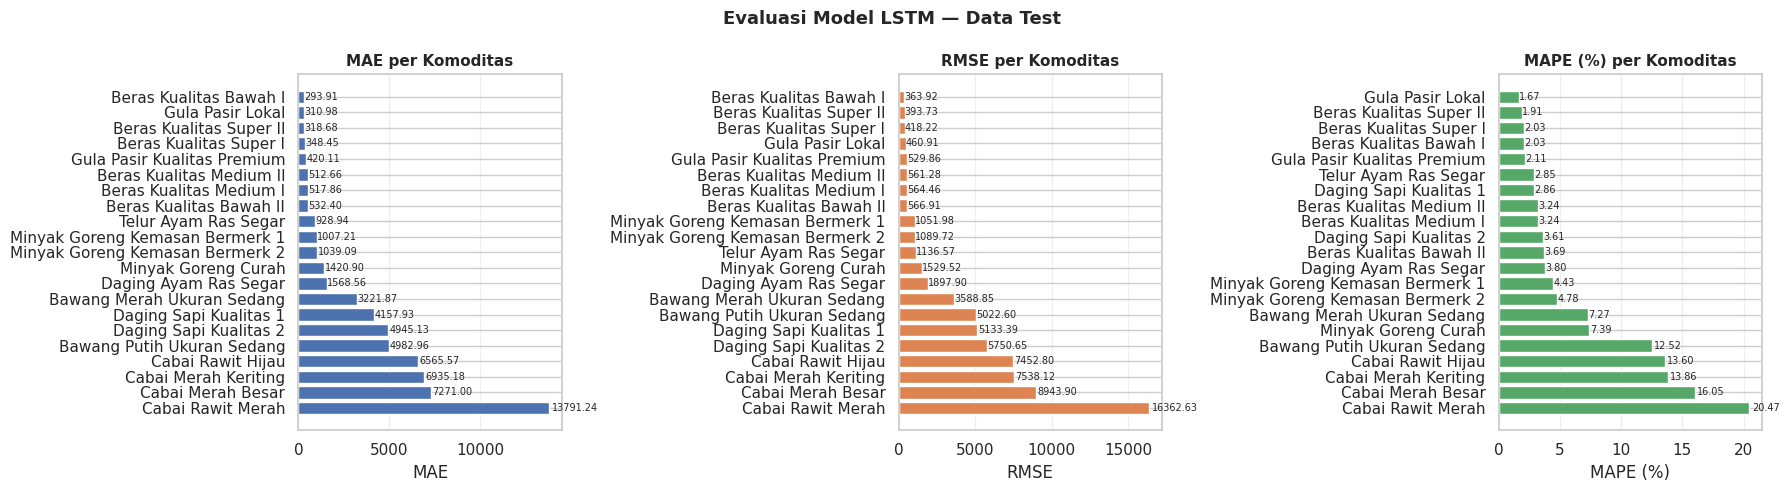

In [26]:
# ----------------------------------------------------------
# 5. Bar chart MAPE per komoditas
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE', 'RMSE', 'MAPE (%)']
colors  = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = eval_df.sort_values(metric)
    ax.barh(sorted_df['Komoditas'], sorted_df[metric], color=color, edgecolor='white')
    ax.set_title(f'{metric} per Komoditas', fontsize=11, fontweight='bold')
    ax.set_xlabel(metric)
    ax.invert_yaxis()           # komoditas terbaik di atas
    ax.grid(axis='x', alpha=0.3)
    # Tambahkan label nilai di ujung bar
    for bar in ax.patches:
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.2f}', va='center', fontsize=7)

plt.suptitle("Evaluasi Model LSTM — Data Test", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 🔍 Visualisasi Prediksi vs Aktual per Komoditas

Grafik ini membandingkan nilai harga aktual (biru) dengan prediksi model (merah) pada data test. Ideal apabila kedua garis berhimpit atau bergerak paralel.

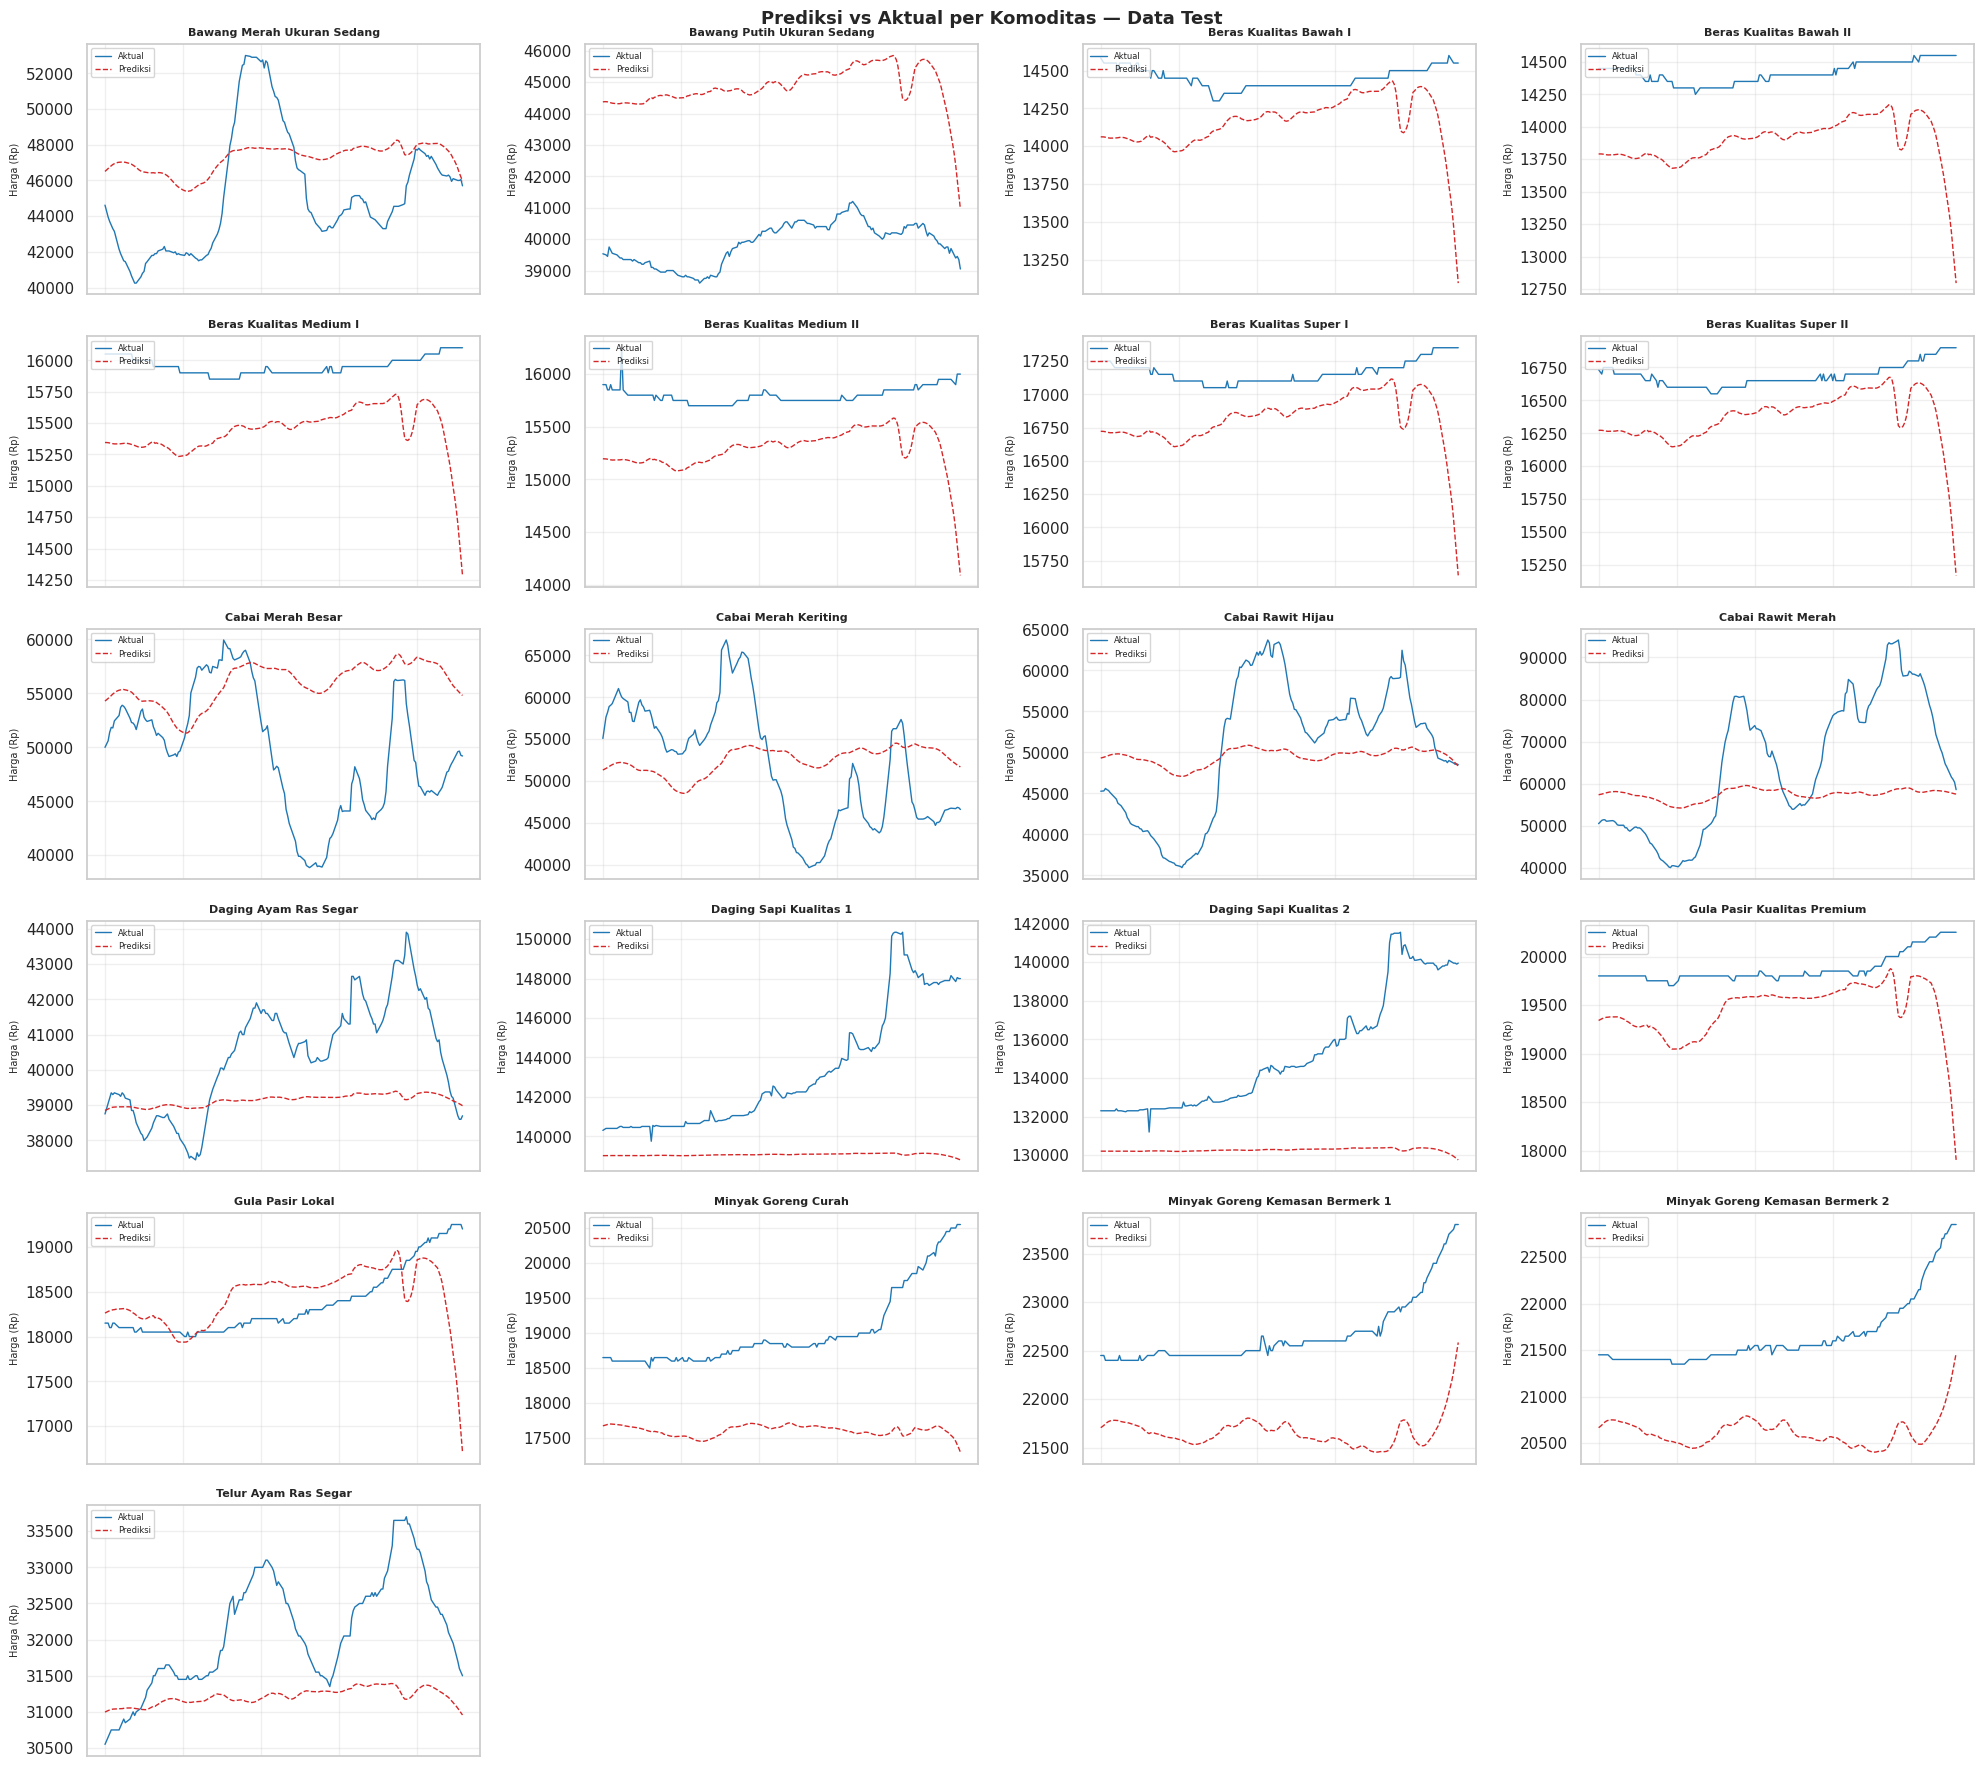

In [28]:

# ----------------------------------------------------------
# 6. Plot prediksi vs aktual untuk setiap komoditas
# ----------------------------------------------------------
N_COLS_VIS = 4
N_PLOTS_VIS = len(commodity_cols)
N_ROWS_VIS  = math.ceil(N_PLOTS_VIS / N_COLS_VIS)

fig, axes = plt.subplots(N_ROWS_VIS, N_COLS_VIS,
                          figsize=(5 * N_COLS_VIS, 3 * N_ROWS_VIS),
                          sharex=False)
axes = axes.flatten()

for i, col in enumerate(commodity_cols):
    ax = axes[i]
    ax.plot(y_true[:, i], label='Aktual',   color='#1f77b4', linewidth=1)
    ax.plot(y_pred[:, i], label='Prediksi', color='#d62728', linewidth=1, linestyle='--')
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Harga (Rp)', fontsize=7)
    ax.tick_params(axis='x', labelbottom=False)
    ax.legend(fontsize=6, loc='upper left')
    ax.grid(True, alpha=0.3)

# Sembunyikan subplot kosong
for j in range(N_PLOTS_VIS, len(axes)):
    axes[j].axis('off')

fig.suptitle("Prediksi vs Aktual per Komoditas — Data Test", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 💾 Simpan Model & Scaler

Model dan scaler disimpan ke disk agar bisa digunakan kembali untuk inferensi tanpa perlu melatih ulang dari awal.

In [31]:
# ----------------------------------------------------------
# 7. Simpan model dan scaler
# ----------------------------------------------------------
# Tentukan nama folder tempat kamu ingin menyimpan
nama_folder = 'model'

# Buat foldernya jika belum ada (exist_ok=True mencegah error jika folder sudah ada)
os.makedirs(nama_folder, exist_ok=True)

# Gabungkan nama folder dengan nama file
path_model = os.path.join(nama_folder, 'model_saya.keras')
path_scaler = os.path.join(nama_folder, 'scaler_saya.pkl')

# Simpan model dan scaler ke path (lokasi) yang baru
model.save(path_model)
print(f"Model berhasil disimpan di: {path_model}")

joblib.dump(scaler, path_scaler)
print(f"Scaler berhasil disimpan di: {path_scaler}")

Model berhasil disimpan di: model/model_saya.keras
Scaler berhasil disimpan di: model/scaler_saya.pkl


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=47ac4af5-104b-4bb7-a535-497aa89239df' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>